# Semantic Evaluation of SDG Reports Over Time

### How has the sentiment and message of the current Sustainable Development Goal Report changed from the original report from 2016? 

### Data Used: 
* 2016 UN SDG Report (inaugural report) https://unstats.un.org/sdgs/report/2016/ 
* 2021 UN SDG Report https://unstats.un.org/sdgs/report/2021/ 
* 2021 SDG Progress Chart https://unstats.un.org/sdgs/report/2021/progress-chart-2021.pdf 
* 2025 UN SDG Report (most recent report) https://unstats.un.org/sdgs/report/2025/The-Sustainable-Development-Goals-Report-2025.pdf



### Method:

1. Conduct EDA on the 2025 report to get informative findings

2. Use facebook/bart-large-mnli model to classify sdg labels
(https://huggingface.co/facebook/bart-large-mnli)

3. Evaluate accuracy of sdg labels

4. Compare Sentiment across different SDG reports

5. Examine how the goals have changed over the past years



### Key Findings

* The report has changed significantly over the past ten years, showing what the UN prioritizes in its messaging
* Sentiment and urgency have shifted across the years, suggesting the UN has been testing different communication styles.
* The most important goals have also changed over time, with different SDGs gaining or losing emphasis.
* Reduced Inequalities is the only SDG that appeared in all three reports, while Life Below Water and Good Health and Well-Being became more prominent
* As 2030 approaches, the reports are likely to become more urgent and consistent, even though progress on many SDGs has slowed or declined



### Relevance

The changes in sentiment and urgency highlight the United Nation's efforts to effectively accomplish the goals as soon as possible. The progress towards these goals has declined since the inaugural report was released, with more inequalities, major pollution concerns, and War. The writing style of the report needed to change to acclimate for the lack of progress to bring more urgency and concern for the critical problems. The UN has confirmed that accomplishing all of the goals by 2030 is impossible, yet they still want the world to recognize how dire some of the issues have become.


### Other Question Pose: 

What goals have showed the most change?

How accurate are current model's SDG labeling technique

### Workflow
1. Background Analysis of 2025 SDG report to see how we can pull out import features
2. Create classification models identifying valuable features in the report:
   * Identify what Goals are linked to each sentence and each chapter
   * Use model to predict what goals are linked to
   * Measure scale of urgency/severity of the situation
   * Run a test on SDG reports from different years to see success and compare evolution of reports

# Background
### United Nations Sustainable Development Goals Background

In 2015, the United Nations adopted the Sustainable Development Goals (SDGs), a set of 17 interconnected goals intended to serve as an urgent global call to action on poverty, inequality, human rights, environmental protection, and sustainable development. These goals apply to all countries, not just developing ones, because the UN recognized that social, economic, and environmental challenges are global and deeply interconnected.

The SDGs establish a shared 2030 deadline for progress across issues such as poverty reduction, food security, health, education, gender equality, clean water, energy access, economic opportunity, sustainable cities, climate action, justice, and international partnerships. Each year, the UN publishes progress reports that assess how countries and regions are advancing toward these goals using measurable indicators and target-level data.

Although the SDGs were designed to create a path toward a more equitable and sustainable world, progress has been uneven. Global crises such as the COVID-19 pandemic, armed conflict, climate change, and rising geopolitical tension have slowed or reversed gains in many areas. As a result, the 2030 target remains extremely ambitious, and many goals will require accelerated action, stronger policy commitment, and greater international cooperation to stay within reach.

https://www.un.org/sustainabledevelopment/development-goals/ 

Each year, the United Nations publishes an official SDG progress report that compiles the latest available data on the 17 goals and their 169 target countries. The report measures progress using a global indicator framework and shows where the world is on track, where progress is too slow, and where setbacks are occurring. Because the SDGs apply to all countries, the report serves as a shared evidence base for monitoring development, inequality, and sustainability worldwide.

### List of Goals

1. No Poverty
2. Zero Hunger
3. Good Health and Well-Being
4. Quality Education
5. Gender Equality
6. Clean Water and Sanitation
7. Affordable and Clean Energy
8. Decent Work and Economic Growth
9. Industry, Innovation, and Infrastructure
10. Reduced Inequalities
11. Sustainable Cities and Communities
12. Responsible Consumption and Production
13. Climate Action
14. Life Below Water
15. Life on Land
16. Peace, Justice, and Strong Institutions
17. Partnerships for the Goals


In [296]:
!pip3 install nltk

Python(68033) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [297]:
!pip3 install spacy

Python(68034) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [298]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import re
import nltk
from nltk.tokenize import sent_tokenize
import spacy

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [299]:
!pip install PyPDF2


Python(68035) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [300]:
import PyPDF2

In [301]:
pdf_2025 = open('The-Sustainable-Development-Goals-Report-2025-2.pdf')

# 2025 SDG Report Exploration

In [302]:
!pip install pdfplumber

Python(68037) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pdfplumber

text = ""

with pdfplumber.open("The-Sustainable-Development-Goals-Report-2025-2.pdf") as pdf:
    for page in pdf.pages:
        text += page.extract_text()

print(text[:2500])


The Sustainable Development Goals Report
2025Contents
Foreword ........................................................2
Introduction......................................................3
Funding data and statistics............................................4
Goal 1 No poverty.......................................................8
Goal 2 Zero hunger.....................................................10
Goal 3 Good health and well-being.......................................12
Goal 4 Quality education................................................16
Goal 5 Gender equality .................................................18
Goal 6 Clean water and sanitation .......................................20
Goal 7 Affordable and clean energy......................................22
Goal 8 Decent work and economic growth................................24
Goal 9 Industry, innovation and infrastructure............................26
Goal 10 Reduced inequalities....................................

In [304]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)  
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = re.sub(r'\s+', ' ', text) 
    return text

cleaned_text = clean_text(text)

In [305]:
#print(cleaned_text)

In [306]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

tokens = word_tokenize(cleaned_text)

stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]

print(filtered_tokens[:50])

['sustainable', 'development', 'goals', 'report', 'contents', 'foreword', 'introduction', 'funding', 'data', 'statistics', 'goal', 'poverty', 'goal', 'zero', 'hunger', 'goal', 'good', 'health', 'wellbeing', 'goal', 'quality', 'education', 'goal', 'gender', 'equality', 'goal', 'clean', 'water', 'sanitation', 'goal', 'affordable', 'clean', 'energy', 'goal', 'decent', 'work', 'economic', 'growth', 'goal', 'industry', 'innovation', 'infrastructure', 'goal', 'reduced', 'inequalities', 'goal', 'sustainable', 'cities', 'communities', 'goal']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [307]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sentiment = sia.polarity_scores(text)
print(sentiment)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


{'neg': 0.071, 'neu': 0.813, 'pos': 0.116, 'compound': 1.0}


Primarily neutral sentiment

In [308]:
sentences = sent_tokenize(text)

sentence_scores = [(sentence, sia.polarity_scores(sentence)['compound']) for sentence in sentences]

In [309]:
#positive impact
sorted(sentence_scores, key=lambda x: x[1], reverse=True)[:5]

[('BirdLife International\nDepartment of Economic and Social Affairs\nDivision for Ocean Affairs and the Law of the Sea\nEconomic and Social Commission for Asia and the Pacific (ESCAP)\nEconomic and Social Commission for Western Asia (ESCWA)\nEconomic Commission for Africa (ECA)\nEconomic Commission for Europe (ECE)\nEconomic Commission for Latin America and the Caribbean (ECLAC)\nFood and Agriculture Organization of the United Nations (FAO)\nInternational Civil Aviation Organization (ICAO)\nInternational Energy Agency (IEA)\nInternational Forum on Total Official Support for Sustainable Development (IFT)\nInternational Labour Organization (ILO)\nInternational Monetary Fund (IMF)\nInternational Organization for Migration (IOM)\nInternational Renewable Energy Agency (IRENA)\nInternational Telecommunication Union (ITU)\nInternational Trade Centre (ITC)\nInternational Union for Conservation of Nature (IUCN)\nInter-Parliamentary Union (IPU)\nJoint United Nations Programme on HIV/AIDS (UNAID

In [310]:
#negative impact
sorted(sentence_scores, key=lambda x: x[1])[:5]

[('Cities require $4.5 trillion\nThe Sustainable Development Goals Report 2025 30Local disaster risk reduction strategies gain Limited civil society participation undermines\nmomentum amid mounting infrastructure threats inclusive urban planning\nfrom climate disasters\nLimited civil society participation in urban planning and management\nDisasters continue to damage critical infrastructure and disrupt essential remains a major barrier to inclusive and sustainable urban development.',
  -0.9719),
 ('estimated 6,687 metric megatons of Forest expansion Deforestation\nCO globally in 2023, more than double the emissions from fossil fuels by the\n2\nSignificant investments in restoration are needed to achieve land degradation neutrality\nLand degradation extends beyond environmental harm, undermining human Central America, Central Asia and the Middle East, restoration efforts\nhealth, driving poverty, worsening food insecurity and fuelling migration.',
  -0.9618),
 ('11 21 19 18 22\n20 13 1

In [311]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform([cleaned_text])

feature_names = vectorizer.get_feature_names_out()

print(feature_names)

['africa' 'and' 'are' 'asia' 'by' 'cent' 'countries' 'data' 'for' 'from'
 'global' 'in' 'is' 'of' 'on' 'per' 'progress' 'the' 'to' 'with']


In [312]:
from collections import Counter

word_counts = Counter(filtered_tokens)

print(word_counts.most_common(20))

[('per', 661), ('cent', 600), ('countries', 291), ('global', 235), ('e', 193), ('data', 170), ('asia', 161), ('progress', 156), ('africa', 141), ('development', 123), ('r', 119), ('p', 117), ('c', 109), ('sustainable', 107), ('n', 107), ('billion', 101), ('america', 100), ('women', 98), ('million', 98), ('goal', 92)]


In [313]:
sentence_scores = {}

for sentence in sentences:
    for word in word_tokenize(sentence.lower()):
        if word in word_counts:
            if sentence not in sentence_scores:
                sentence_scores[sentence] = word_counts[word]
            else:
                sentence_scores[sentence] += word_counts[word]

# get top sentences
summary = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:5]

for s in summary:
    print(s)

rose from 58.6 in 2016 to 69.7 in 2023, owing to the heightened demand forSDG progress by target
1.1 International poverty 2.1 Undernourishment 3.1 Maternal mortality 4.1 Effective learning 5.1 Legal frameworks
and food security outcomes on gender equality
1.2 National poverty 3.2 Child mortality
2.2 Malnutrition 4.2 Early childhood 5.2 Violence against
1.3 Social protection 3.3 Communicable
education women and girls
2.3 Small-scale food diseases
1.4 Access to basic
producers 4.3 TVET and tertiary 5.3 Child marriage
services 3.4 NCD and mental health
education
2.4 Productive and 5.4 Unpaid care and
1.5 Resilience to disasters 3.5 Substance abuse and
sustainable agriculture 4.4 Skills for employment domestic work
treatment
1.a Government spending
2.5 Genetic resources 4.5 Equal access to 5.5 Women in leadership
on essential services 3.6 Road traffic accidents
for agriculture education
5.6 Reproductive health
1.b Poverty eradication 3.7 Sexual and reproductive
2.a Investment in 4.6 Adult

In [314]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

Python(68047) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.7 MB/s  0:00:03 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [315]:
nlp = spacy.load("en_core_web_sm")
locations = {'asia': 0, 'africa':0, 'north america': 0, 'south america': 0, 'europe': 0, 'oceania': 0, 'australia': 0, 'latin america': 0, 'northern america':0}

doc = nlp(cleaned_text)

found_continents = []

for ent in doc.ents:
    entity_text = ent.text.lower()
    if entity_text in locations:
        locations[entity_text] += 1 

print(locations)

{'asia': 48, 'africa': 66, 'north america': 1, 'south america': 1, 'europe': 36, 'oceania': 4, 'australia': 41, 'latin america': 32, 'northern america': 33}


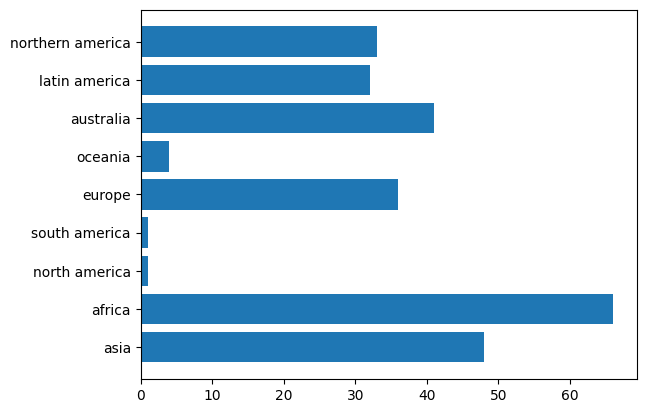

In [316]:
names = list(locations.keys())
values = list(locations.values())

plt.barh(names, values)
plt.show()

Africa was mentioned the most times out of all continents throughout the 2025 report. This was not surprising to me because the continent and it's countries were highlighted many times throughout for both praise on progress that is being achieved and also what needs to change to achieve the SDG's. Asia had the second highest frequency with more praise for their significant rise in technology and equality.

# 2025 SDG Machine Learning

In [317]:
text = ""

with pdfplumber.open("The-Sustainable-Development-Goals-Report-2025-2.pdf") as pdf:
    for page in pdf.pages:
        text += page.extract_text()

print(text[:2500])

The Sustainable Development Goals Report
2025Contents
Foreword ........................................................2
Introduction......................................................3
Funding data and statistics............................................4
Goal 1 No poverty.......................................................8
Goal 2 Zero hunger.....................................................10
Goal 3 Good health and well-being.......................................12
Goal 4 Quality education................................................16
Goal 5 Gender equality .................................................18
Goal 6 Clean water and sanitation .......................................20
Goal 7 Affordable and clean energy......................................22
Goal 8 Decent work and economic growth................................24
Goal 9 Industry, innovation and infrastructure............................26
Goal 10 Reduced inequalities....................................

In [318]:
def clean_raw_text(text):
    text = re.sub(r'\n+', ' ', text)
    
    # Fix hyphenated words across lines (e.g., "develop-\nment")
    text = re.sub(r'-\s+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

cleaned_text = clean_raw_text(text)

In [319]:
import nltk
nltk.download('punkt')


sentences = sent_tokenize(cleaned_text)

print(sentences[:5])

['The Sustainable Development Goals Report 2025Contents Foreword ........................................................2 Introduction......................................................3 Funding data and statistics............................................4 Goal 1 No poverty.......................................................8 Goal 2 Zero hunger.....................................................10 Goal 3 Good health and well-being.......................................12 Goal 4 Quality education................................................16 Goal 5 Gender equality .................................................18 Goal 6 Clean water and sanitation .......................................20 Goal 7 Affordable and clean energy......................................22 Goal 8 Decent work and economic growth................................24 Goal 9 Industry, innovation and infrastructure............................26 Goal 10 Reduced inequalities..................................

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [320]:
import nltk
from nltk.corpus import stopwords
import re

In [ ]:
nltk.download('words')
nltk.download('stopwords') 

english_words = set(nltk.corpus.words.words())
stop_words = set(stopwords.words('english')) 

def clean_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z0-9\s']", '', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    
    tokens = sentence.split()

    cleaned_tokens = [
        word for word in tokens 
        if word not in stop_words  
        and (
            (word in english_words and (len(word) > 1 or word in ['a', 'i']))
            or word.isdigit()
        )
    ]

    return " ".join(cleaned_tokens)

cleaned_sentences = [clean_sentence(s) for s in sentences]



[nltk_data] Downloading package words to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [322]:
cleaned_sentences = [
    s for s in cleaned_sentences 
    if len(s.split()) > 5  
]

In [323]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(cleaned_text)

sentences = [sent.text.strip() for sent in doc.sents]

print(sentences[21:30])

['Around the world, young people, Forum, the Second United Nations Food Systems Summit and the Second communities, civil society and local leaders are stepping up their action to World Summit for Social Development.', 'deliver on the promise of the SDGs.', 'The Sustainable Development Goals remain within reach, but only if we act Despite these important gains, conflicts, climate chaos, geopolitical tensions decisively and act now.', 'Together, we can still build the sustainable future and economic shocks continue to obstruct progress at the pace and scale everyone, everywhere, deserves.', 'needed to meet the 2030 target.', 'This year’s Sustainable Development Goals Report finds that only 35 per cent of SDG targets are on track or making moderate progress.', 'Nearly half are moving too slowly and, alarmingly, 18 per cent are in reverse.', 'We face a global development emergency.', 'Over 800 million people are trapped in extreme poverty.']


In [324]:
sentiment_rating = []
pos_sig = {}
neg_sig = {}

for s in cleaned_sentences:
    score = sia.polarity_scores(s)
    print(s, score)
    compound_value = score['compound']
    if score['compound'] > .75:
        pos_sig.update({s: score['compound']})
    elif score['compound'] < -.75:
        neg_sig.update({s: score['compound']})
    sentiment_rating.append(compound_value)

sustainable development report foreword 2 data goal 1 goal 2 zero goal 3 good health goal 4 quality goal 5 gender equality 18 goal 6 clean water sanitation 20 goal 7 affordable clean goal 8 decent work economic goal 9 industry innovation goal 10 reduced goal 11 sustainable 30 goal 12 responsible consumption production 32 goal 13 climate goal 14 life goal 15 life goal 16 peace justice strong 40 goal 17 progress target 44 note reader sustainable development report ten since world transformative 2030 agenda making massive investment robust sustainable development opportunity urgent acceleration {'neg': 0.0, 'neu': 0.687, 'pos': 0.313, 'compound': 0.9837}
also removing full participation obligation take stock progress acknowledge act public life ending violence urgency responsibility {'neg': 0.196, 'neu': 0.67, 'pos': 0.134, 'compound': -0.3182}
tackling poverty inequality digital divide since 2015 millions access essential {'neg': 0.268, 'neu': 0.732, 'pos': 0.0, 'compound': -0.5106}
tech

In [325]:
pos_sig

{'sustainable development report foreword 2 data goal 1 goal 2 zero goal 3 good health goal 4 quality goal 5 gender equality 18 goal 6 clean water sanitation 20 goal 7 affordable clean goal 8 decent work economic goal 9 industry innovation goal 10 reduced goal 11 sustainable 30 goal 12 responsible consumption production 32 goal 13 climate goal 14 life goal 15 life goal 16 peace justice strong 40 goal 17 progress target 44 note reader sustainable development report ten since world transformative 2030 agenda making massive investment robust sustainable development opportunity urgent acceleration': 0.9837,
 'regardless wealth capacity address climate change pandemic report story remarkable human resilience ingenuity': 0.7783,
 'validate fundamental evidence report transformation possible premise 2030 agenda sustainable development achievable combine proven political courage adequate combine sustained political': 0.836,
 '3 data statistics essential infrastructure development electricity m

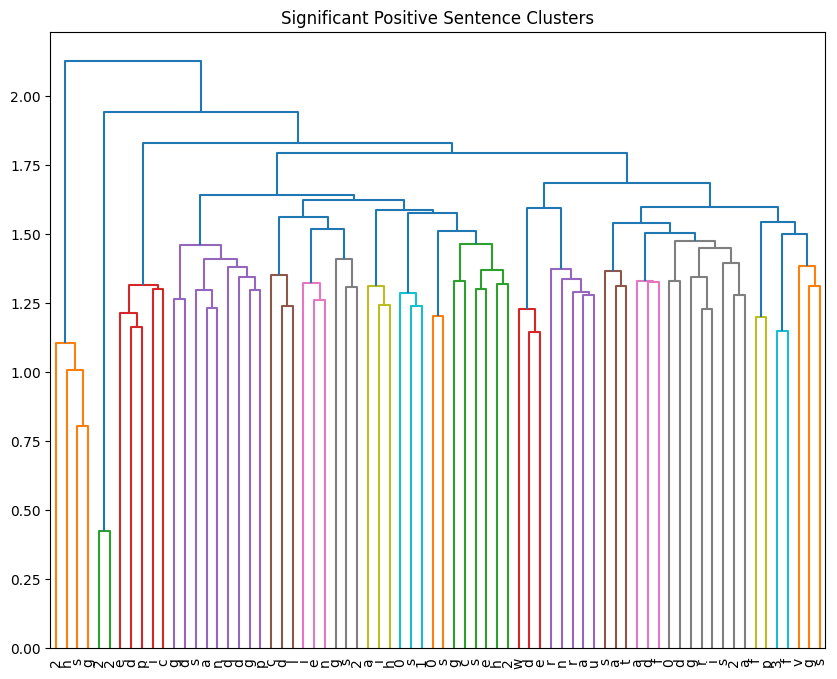

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(list(pos_sig.keys()))

linked = linkage(X.toarray(), method='ward')

plt.figure(figsize=(10, 8))
dendrogram(linked, 
           labels=[s[0] for s in pos_sig.keys()], 
           leaf_font_size=10)
plt.title("Significant Positive Sentence Clusters")
plt.show()

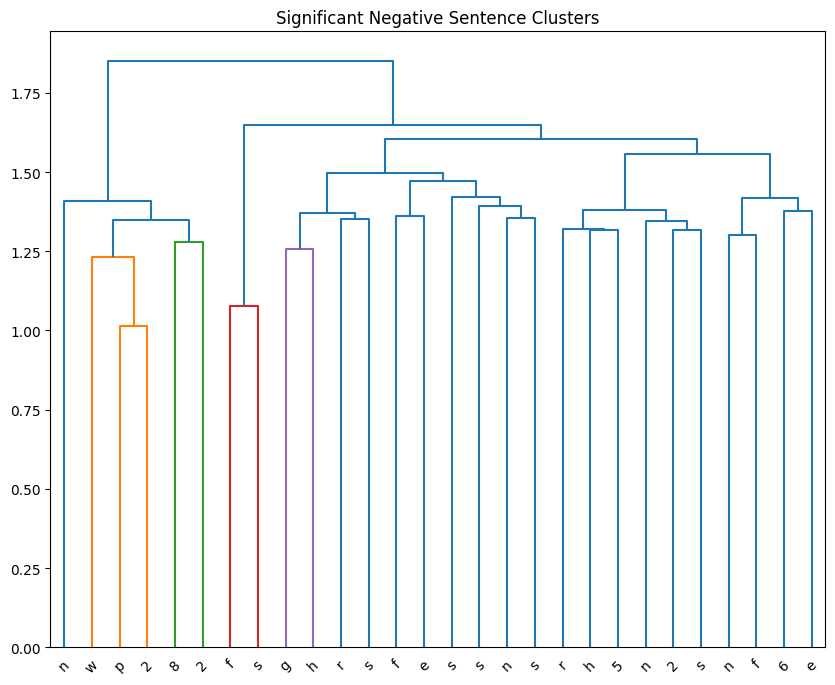

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(list(neg_sig.keys()))

linked = linkage(X.toarray(), method='ward')

plt.figure(figsize=(10, 8))
dendrogram(linked, 
           labels=[s[0] for s in neg_sig.keys()], 
           leaf_font_size=10)
plt.title("Significant Negative Sentence Clusters")
plt.show()

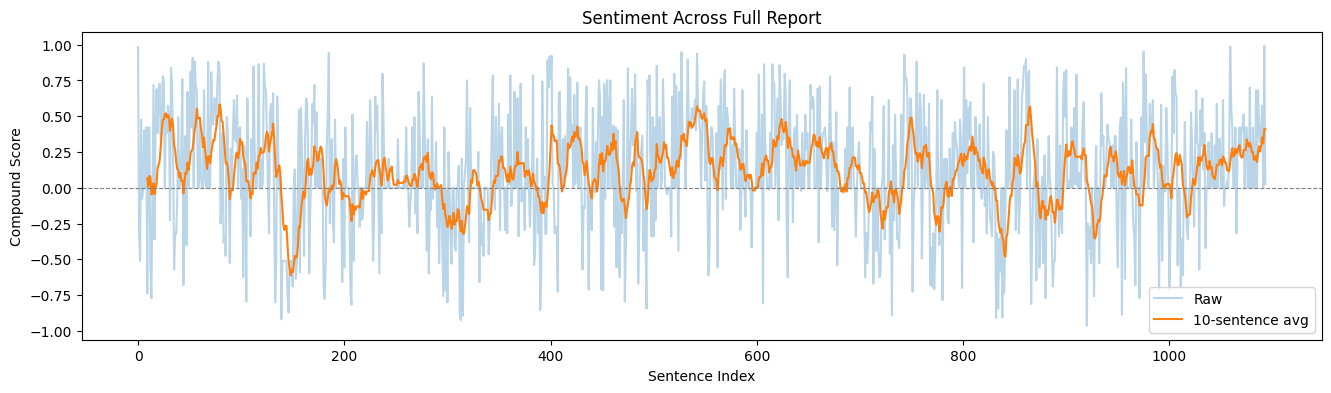

In [328]:
plt.figure(figsize=(16, 4))
plt.plot(sentiment_rating, alpha=0.3, label='Raw')
plt.plot(pd.Series(sentiment_rating).rolling(10).mean(), label='10-sentence avg')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Sentiment Across Full Report")
plt.xlabel("Sentence Index")
plt.ylabel("Compound Score")
plt.legend()
plt.show()

The blue line represents the raw sentiment scores of all of the sentences in the 2025 SDG report, while the orange line represents the rolling average of every ten sentences. When the average of each cluster is taken, it diminishes the impact of the sentences that have strong scores when they are near sentences with juxtaposing or neutral sentiments. This causes the average score to be more regularized compared to the raw. This plot shows the power that individual sentences have compared to a 10 sentence average, proving the impact that each individual sentence holds

In [335]:
TfidfVectorizer().fit_transform(cleaned_sentences)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15280 stored elements and shape (1094, 2797)>

In [336]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50)  
X = vectorizer.fit_transform(cleaned_sentences)

In [337]:
feature_names = vectorizer.get_feature_names_out()
print(feature_names)

['10' '20' '2015' '2022' '2023' '2024' '2025' '2030' '40' '60' 'access'
 'average' 'billion' 'cent' 'central' 'climate' 'data' 'despite'
 'development' 'eastern' 'economic' 'education' 'energy' 'food' 'global'
 'goal' 'growth' 'health' 'however' 'international' 'million' 'national'
 'new' 'northern' 'one' 'people' 'per' 'percentage' 'population'
 'progress' 'rate' 'remains' 'report' 'share' 'since' 'southern'
 'sustainable' 'united' 'water' 'world']


In [338]:
import pandas as pd

df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)

df_tfidf.head()

,10,20,2015,2022,2023,2024,2025,2030,40,60,...,rate,remains,report,share,since,southern,sustainable,united,water,world
0,0.051681,0.051084,0.000000,0.0,0.0,0.0,0.0,0.054619,0.051886,0.0,...,0.0,0.0,0.105039,0.0,0.051681,0.0,0.19706,0.0,0.059052,0.051886
1,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.000000
2,0.000000,0.000000,0.494294,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.597464,0.0,0.00000,0.0,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.000000


In [339]:
word_importance = df_tfidf.sum().sort_values(ascending=False)

print(word_importance.head(15))

per            163.814045
cent           152.239892
global          77.204195
data            64.598871
progress        58.190975
2023            52.647046
2024            50.597015
2015            47.839465
billion         42.557463
million         38.850455
climate         36.543966
development     35.905239
sustainable     35.779026
northern        33.596857
however         32.904884
dtype: float64


In [340]:
sentence_scores = X.sum(axis=1)

sentence_scores = sentence_scores.A1

top_index = sentence_scores.argmax()

print("Most important sentence:")
print(cleaned_sentences[top_index])

Most important sentence:
rose 586 2016 697 2023 owing demand progress target 11 international poverty 21 undernourishment 31 maternal mortality 41 effective learning 51 legal food security gender equality 12 national poverty 32 child mortality 22 malnutrition 42 early childhood 52 violence 13 social protection 33 communicable education 23 food 14 access basic 43 tertiary 53 child marriage 34 mental health education 24 productive 54 unpaid care 15 resilience 35 substance abuse sustainable agriculture 44 employment domestic work treatment government spending 25 genetic 45 equal access 55 leadership essential 36 road traffic agriculture education 56 reproductive health poverty eradication 37 sexual reproductive investment 46 adult literacy access health agriculture equal economic 38 universal health agricultural export 47 sustainable coverage development education technology 39 health impact food price education empowerment pollution oda tobacco control qualified immunization coverage hea

In [341]:
for i, row in enumerate(X.toarray()):
    top_words = [feature_names[j] for j in row.argsort()[-5:]]
    print(f"Sentence {i}: {top_words}")

Sentence 0: ['water', 'report', 'development', 'sustainable', 'goal']
Sentence 1: ['economic', 'education', 'average', 'world', 'progress']
Sentence 2: ['education', 'billion', '2015', 'since', 'access']
Sentence 3: ['economic', 'education', 'average', 'world', 'population']
Sentence 4: ['economic', 'education', 'billion', 'world', 'people']
Sentence 5: ['economic', 'education', 'world', 'per', 'cent']
Sentence 6: ['education', 'energy', 'billion', 'world', 'access']
Sentence 7: ['food', 'per', 'cent', 'development', 'new']
Sentence 8: ['development', 'people', 'food', 'united', 'world']
Sentence 9: ['world', 'development', 'sustainable', 'climate', 'despite']
Sentence 10: ['average', 'world', 'progress', 'sustainable', 'economic']
Sentence 11: ['cent', 'progress', 'development', 'sustainable', 'report']
Sentence 12: ['economic', 'education', 'world', 'per', 'cent']
Sentence 13: ['education', 'food', 'world', 'million', 'people']
Sentence 14: ['education', 'billion', 'world', '2024', '

<Axes: >

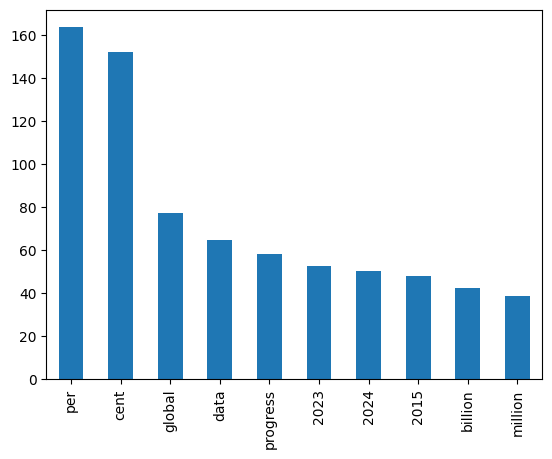

In [342]:
word_importance.head(10).plot(kind='bar')

Percent, global, data, and progress were labeled as the most powerful words in the 2025 SDG report. These words are fitting because they are all powerful parts of a contextual whole. Percent is powerful because it's always paired with statistics that have high value to the document. Statistics bring evidence and high meaning, so words correlated with this high value will have higher ratings. Global, data, and progress are all rated highly because they are prevalent in making steps toward achieving the SDG's

# Label Classification

In [343]:
!pip install transformers torch nltk pandas scikit-learn

Python(68056) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [344]:
data = text
data[:2500]

'The Sustainable Development Goals Report\n2025Contents\nForeword ........................................................2\nIntroduction......................................................3\nFunding data and statistics............................................4\nGoal 1 No poverty.......................................................8\nGoal 2 Zero hunger.....................................................10\nGoal 3 Good health and well-being.......................................12\nGoal 4 Quality education................................................16\nGoal 5 Gender equality .................................................18\nGoal 6 Clean water and sanitation .......................................20\nGoal 7 Affordable and clean energy......................................22\nGoal 8 Decent work and economic growth................................24\nGoal 9 Industry, innovation and infrastructure............................26\nGoal 10 Reduced inequalities.....................

In [345]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')


sentences = sent_tokenize(data)

df = pd.DataFrame({'sentence': sentences})

print(df.head())
print(f"Total sentences: {len(df)}")

                                            sentence
0  The Sustainable Development Goals Report\n2025...
1  It also requires removing barriers to the full...
2  and ensuring equal access to education, employ...
3  It\nmeans tackling poverty and inequality head...
4  More\nand ensuring that technology, including ...
Total sentences: 1442


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jackhamilton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [346]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 8235.13it/s]


In [347]:
sdg_labels = [
    "No Poverty",
    "Zero Hunger",
    "Good Health and Well-being",
    "Quality Education",
    "Gender Equality",
    "Clean Water and Sanitation",
    "Affordable and Clean Energy",
    "Decent Work and Economic Growth",
    "Industry, Innovation and Infrastructure",
    "Reduced Inequalities",
    "Sustainable Cities and Communities",
    "Responsible Consumption and Production",
    "Climate Action",
    "Life Below Water",
    "Life on Land",
    "Peace, Justice and Strong Institutions",
    "Partnerships for the Goals"
]

In [348]:
from tqdm import tqdm
tqdm.pandas()

df_clean = df[df['sentence'].str.split().str.len() > 8].copy()

def classify_sdg(text):
    result = classifier(text, sdg_labels, multi_label=True)
    return result['labels'], result['scores']

df_clean[['labels', 'scores']] = df_clean['sentence'].progress_apply(
    lambda x: pd.Series(classify_sdg(x))
)

df_sample = df_clean.copy()

def filter_labels(labels, scores, threshold=0.5):
    filtered = [label for label, score in zip(labels, scores) if score > threshold]
    return filtered if filtered else ["Unclassified"]

df_sample['sdgs'] = df_sample.apply(
    lambda row: filter_labels(row['labels'], row['scores']),
    axis=1
)

df_sample.head()
df_sample.head()

100%|██████████| 1209/1209 [34:38<00:00,  1.72s/it] 


,sentence,labels,scores,sdgs
0,The Sustainable Development Goals Report\n2025...,"[Decent Work and Economic Growth, Life Below W...","[0.9359639286994934, 0.9214932322502136, 0.919...","[Decent Work and Economic Growth, Life Below W..."
1,It also requires removing barriers to the full...,"[Gender Equality, Reduced Inequalities, Decent...","[0.6422167420387268, 0.6267823576927185, 0.426...","[Gender Equality, Reduced Inequalities]"
2,"and ensuring equal access to education, employ...","[Decent Work and Economic Growth, Reduced Ineq...","[0.8734457492828369, 0.8167830109596252, 0.511...","[Decent Work and Economic Growth, Reduced Ineq..."
3,It\nmeans tackling poverty and inequality head...,"[Reduced Inequalities, Decent Work and Economi...","[0.40159541368484497, 0.28071129322052, 0.2050...",[Unclassified]
4,"More\nand ensuring that technology, including ...","[Decent Work and Economic Growth, Reduced Ineq...","[0.4667853116989136, 0.4588717520236969, 0.367...",[Unclassified]


In [349]:
def filter_labels(labels, scores, threshold=0.5):
    filtered = [label for label, score in zip(labels, scores) if score > threshold]
    return filtered if filtered else ["Unclassified"]

df_sample['sdgs'] = df_sample.apply(
    lambda row: filter_labels(row['labels'], row['scores']),
    axis=1
)

In [350]:
from collections import Counter

all_sdgs = df_sample['sdgs'].explode()
sdg_counts = Counter(all_sdgs)

print(sdg_counts)

Counter({'Reduced Inequalities': 730, 'Unclassified': 328, 'Decent Work and Economic Growth': 312, 'Responsible Consumption and Production': 192, 'Climate Action': 141, 'Clean Water and Sanitation': 88, 'Sustainable Cities and Communities': 84, 'Good Health and Well-being': 74, 'Affordable and Clean Energy': 68, 'Gender Equality': 38, 'Partnerships for the Goals': 31, 'Quality Education': 30, 'Industry, Innovation and Infrastructure': 29, 'Peace, Justice and Strong Institutions': 25, 'Life Below Water': 15, 'No Poverty': 12, 'Life on Land': 12, 'Zero Hunger': 8})


In [351]:
sdg_df = pd.DataFrame(sdg_counts.items(), columns=['SDG', 'count'])
sdg_df = sdg_df.sort_values(by='count', ascending=False)

sdg_df

,SDG,count
4,Reduced Inequalities,730
17,Unclassified,328
0,Decent Work and Economic Growth,312
9,Responsible Consumption and Production,192
5,Climate Action,141
3,Clean Water and Sanitation,88
11,Sustainable Cities and Communities,84
7,Good Health and Well-being,74
6,Affordable and Clean Energy,68
13,Gender Equality,38


In [352]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3791.86it/s]


# Report Differences From 2016, 2021, 2025

In [353]:
# report function

def process_report(pdf_path, year):
 
    raw_text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            raw_text += page.extract_text() or ""

    text = re.sub(r'\n+', ' ', raw_text)
    text = re.sub(r'-\s+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()


    sentences = sent_tokenize(text)
    df = pd.DataFrame({'sentence': sentences})
    df = df[df['sentence'].str.split().str.len() > 8].copy().reset_index(drop=True)

    print(f"[{year}] Classifying {len(df)} sentences...")
    df[['labels', 'scores']] = df['sentence'].progress_apply(
        lambda x: pd.Series(classify_sdg(x))
    )

    df['sdgs'] = df.apply(
        lambda row: filter_labels(row['labels'], row['scores']),
        axis=1
    )

    df['urgency'] = df['sentence'].apply(
        lambda x: -sia.polarity_scores(x)['compound']
    )

    df['year'] = year
    df_tidy = (
        df[['sentence', 'sdgs', 'urgency', 'year']]
        .explode('sdgs')
        .rename(columns={'sdgs': 'sdg'})
        .query("sdg != 'Unclassified'")
        .reset_index(drop=True)
    )

    print(f"[{year}] Done — {len(df_tidy)} sentence-SDG pairs")
    return df_tidy
    

In [354]:
df_2025 = process_report("The-Sustainable-Development-Goals-Report-2025-2.pdf", 2025)
df_2021 = process_report("sdg_report_2021.pdf", 2021)
df_2016 = process_report("sdg_report_2016.pdf", 2016)

df_master = pd.concat([df_2016, df_2021, df_2025], ignore_index=True)

[2025] Classifying 1205 sentences...


100%|██████████| 1205/1205 [33:30<00:00,  1.67s/it]


[2025] Done — 1904 sentence-SDG pairs
[2021] Classifying 1077 sentences...


100%|██████████| 1077/1077 [27:30<00:00,  1.53s/it] 


[2021] Done — 1274 sentence-SDG pairs
[2016] Classifying 605 sentences...


100%|██████████| 605/605 [22:05<00:00,  2.19s/it]


[2016] Done — 898 sentence-SDG pairs


In [355]:
df_master.head(20)

,sentence,sdg,urgency,year
0,The Sustainable Development Goals Report 2016 ...,Decent Work and Economic Growth,-0.9790,2016
1,The Sustainable Development Goals Report 2016 ...,No Poverty,-0.9790,2016
2,The Sustainable Development Goals Report 2016 ...,Partnerships for the Goals,-0.9790,2016
3,The Sustainable Development Goals Report 2016 ...,Reduced Inequalities,-0.9790,2016
4,The Sustainable Development Goals Report 2016 ...,"Peace, Justice and Strong Institutions",-0.9790,2016
5,The Sustainable Development Goals Report 2016 ...,Affordable and Clean Energy,-0.9790,2016
6,The Sustainable Development Goals Report 2016 ...,Responsible Consumption and Production,-0.9790,2016
7,The Sustainable Development Goals Report 2016 ...,Zero Hunger,-0.9790,2016
8,The Sustainable Development Goals Report 2016 ...,"Industry, Innovation and Infrastructure",-0.9790,2016
9,The Sustainable Development Goals Report 2016 ...,Clean Water and Sanitation,-0.9790,2016


In [ ]:
#Does the classifier reliably map sentences to the right goal?

this = df_master.sample(n=20)

for idx, row in this.iterrows():
    print(f"{idx}: {row['sentence']}\nSDG: {row['sdg']}\n")

243: World 5 6 0 2 4 6 8 10 12 14 16 2000 2014 Note: The population coverage for developed regions is less than 50 per cent for all periods between 2000 and 2014.
SDG: Decent Work and Economic Growth

1176: n A a d n e W i m sm H ic s O , t m o su o s r s u v t p e c p y o o s u r h n t o t t r w h ie e s s t hat Au N st e r w al i Z a e a a n la d n N d ort E h u e r r o n p A e m an er d ica an L d a t t i h n e A C m ar e ib ri b c e a a S n outh E a E s a t s e t r e n r n a N n A d o s r i t a hern W A e fr s i t c e a r n a n A d sia S C o e u n t t h ra e l r n a n S A d u s b ia -Saharan Africa Oceania* approximately 9 out of 10 responding countries have defined a core Regional mean set of essential health services to be maintained.
SDG: Reduced Inequalities

1652: g ories are spaced apart, Central and Southern Asia 15 1 7 93 Among peopleN ourmigbienr alatbienlgs s fhrooumld bNe oinrstidhee cronlo Ar bfarrisc (aid aeanlldy) Wande 0spt3e frrno mA esdigae, .
SDG: Reduced Inequali

The sample of 20 sentences has generally accurately produced sdg classification labels. Many sentences could fall under multiple SDG's, but the classifier does a good job at identifying which one's are the most important. An additional consideration is that many sentences in the SDG's are very verbose and are describing graphics, or general concepts. These sentences are assigned a label even though they might not belong with a specific SDG's.

In [438]:
# Compare 10 sentences and store in a table and compare my labels to classifier labels

test_sentences = [71, 199, 211, 325, 492, 585, 733, 1555, 2947, 3230]


self_label = df_master.loc[test_sentences]

self_label



,sentence,sdg,urgency,year
71,5 OverviewGoal 6: Ensure availability and sust...,Clean Water and Sanitation,-0.3818,2016
199,This includes social protection benefits for t...,Reduced Inequalities,-0.0953,2016
211,Social protection programmes include social as...,Reduced Inequalities,-0.0000,2016
325,"50 Globally, the proportion of women aged 20 t...",Reduced Inequalities,-0.0000,2016
492,"Manufacturing value added per capita, 2005 and...",Reduced Inequalities,-0.8750,2016
585,Though the percentage of Eastern Asia 25 city ...,Reduced Inequalities,0.0772,2016
733,Total ODA from DAC countries as a share of the...,Decent Work and Economic Growth,0.2263,2016
1555,13 17 Europe and Northern America 13 11.5 12 W...,Decent Work and Economic Growth,0.3089,2021
2947,This finding is based on using safely managed ...,Good Health and Well-being,-0.8176,2025
3230,Without stronger policies focusing on job qual...,Reduced Inequalities,0.2924,2025


In [437]:

df_master.loc[71, 'sentence']

'5 OverviewGoal 6: Ensure availability and sustainable management of water and sanitation for all Goal 6 goes beyond drinking water, sanitation and hygiene to also address the 663 million still use quality and sustainability of water resources.'

# Comparisons of Self-Given Labels vs Classifier Labels

| Index | Sentence | My Label | Classifier Label |
| ----- | ----- | ------| ------ |
| 75    | 5 OverviewGoal 6: Ensure availability and sustainable management of water and sanitation for all Goal 6 goes beyond drinking water, sanitation and hygiene to also address the 663 million still use quality and sustainability of water resources         | Clean water and sanitation        | Clean water and sanitation                |
| 199    |This includes social protection benefits for the poor and most vulnerable and ensuring that people harmed by conflict and natural hazards receive adequate support, including access to basic services.          | Reduced Inequalities         | Reduced Inequalities                 |
| 211    | Social protection programmes include social assistance, such as cash transfers, school feeding and targeted food assistance.         | Reduced Inequalites         | Reduced Inequalities                 |
| 325    | 50 Globally, the proportion of women aged 20 to 24 who reported that they were married before their eighteenth 40 birthdays dropped from 32 per cent around 1990 to 30 26 per cent around 2015.          | Gender Equality         | Reduced Inequalities                 |
| 492    |Manufacturing value added per capita, 2005 and 2015 (constant 2010 US dollars) The untapped manufacturing potential of the least developed countries suggests 62 Least developed countries 98 significant growth opportunities 119 Landlocked developing countries Manufacturing is one of the principal engines of economic 149 growth          | Industry, Innovation and Infrastructure         | Reduced Inequalities                 |
| 585    | Though the percentage of Eastern Asia 25 city dwellers living in such conditions declined over 21 Western Asia 25 the last decade, more than 880 million people around Oceania 24 the world were still living in slums in 2014.         | Sustainable Cities and Communities         | Reduced Inequalities                 |
| 733    | Total ODA from DAC countries as a share of their gross national income (GNI) was 0.30 per cent, on par with 2014.         | Decent Work and Economic Growth         | Decent Work and Economic Growth                 |
| 1555   | 13 17 Europe and Northern America 13 11.5 12 Worldwide, young women are twice as likely as young men to be Australia and New Zealand 9 jobless and not engaged in education or training.          | Gender Equality & Decent Work and Economic Growth        |  Decent Work and Economic Growth                |
| 2947   | This finding is based on using safely managed drinking water rose from 68 to 74 per cent, safely data from 130 Member States and 12 territories, covering 84 per cent of the managed sanitation coverage increased from 48 to 58 per cent, and basic global population.          | Clean Water and Sanitation         | Good Health and Well Being                 |
| 3230   | Without stronger policies focusing on job quality, informal By 2024, 57.8 per cent of the global workforce was informally employed, employment will continue to hinder decent work and inclusive development.        |  Decent Work and Economic Growth        | Reduced Inequalities                 |

The model overclassifies Reduced Inequalities for almost half of the sentences. Even though Reduced Inequalities is important, the distribution shouldn't be imbalanced for the SDG's. The problem is that Reduced Inequalities is such a broad term that applies to a lot of other SDG's (water inequality, food inequality, gender inequality, economic inequality, etc.), so if the sentence is not descriptive enough, then it will list it as Reduced Inequalities. The model recognizes that it is an inequality, but it has trouble discriminating the specific goals from each other. The model is not incorrect, it just is not as accurate as it could be. 

In [356]:
df_master['sdg'].value_counts()

sdg
Reduced Inequalities                       1534
Decent Work and Economic Growth             690
Responsible Consumption and Production      421
Climate Action                              300
Clean Water and Sanitation                  220
Sustainable Cities and Communities          196
Good Health and Well-being                  175
Affordable and Clean Energy                 138
Gender Equality                              80
Partnerships for the Goals                   79
Industry, Innovation and Infrastructure      65
Quality Education                            55
Peace, Justice and Strong Institutions       44
No Poverty                                   26
Life Below Water                             23
Life on Land                                 21
Zero Hunger                                   9
Name: count, dtype: int64

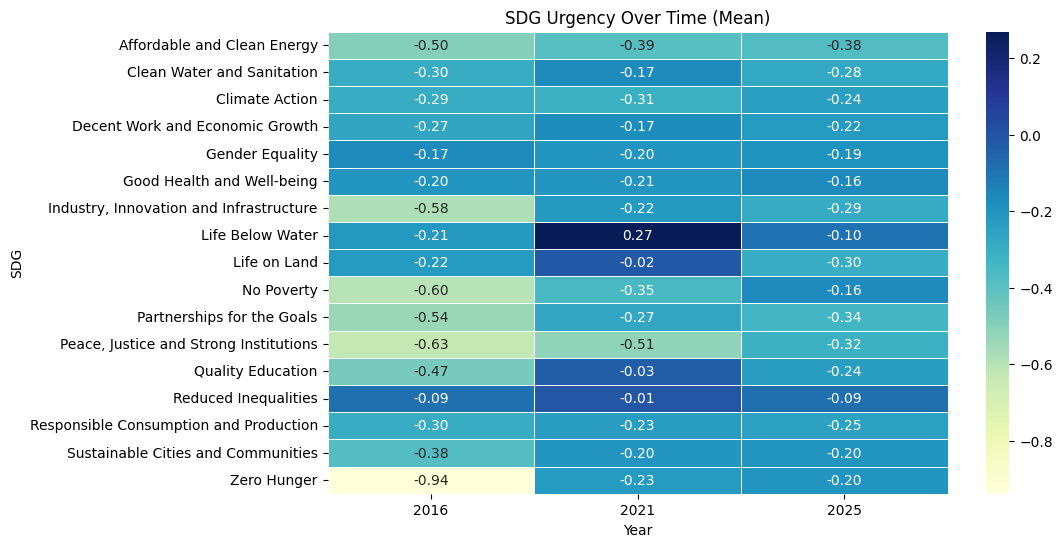

In [357]:
#heatmap of urgency

import seaborn as sns

pivot_df = df_master.pivot_table(
    index="sdg", columns="year", values="urgency", aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.5)

plt.title("SDG Urgency Over Time (Mean)")
plt.xlabel("Year")
plt.ylabel("SDG")
plt.show()

I expected that the SDG's would have similar ratings across all three reports (2016, 2021, and 2025). While there is a lot of consistency across all three years for about half of the goals, around half show inconsistencies across all of the reports. The urgency scores in 2016 started off as fairly positive, then shifted to a blend of slightly positive and slightly negative in 2021, and then moved into consistently slightly positive scores across all of the goals.

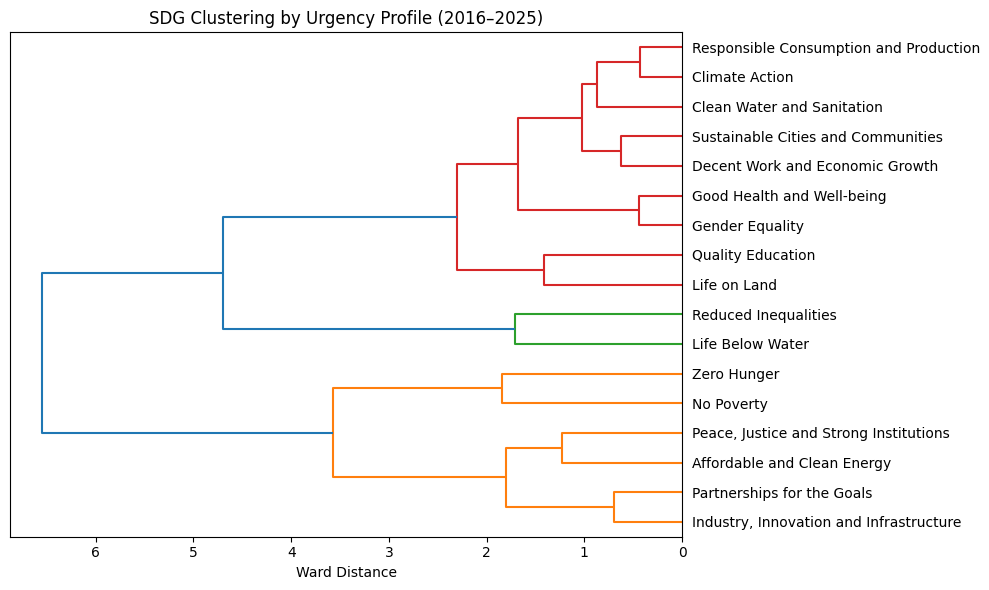

In [378]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

urgency_matrix = df_master.pivot_table(
    index='sdg', columns='year', values='urgency', aggfunc='mean'
).dropna()  

scaler = StandardScaler()
scaled = scaler.fit_transform(urgency_matrix)

linked = linkage(scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    labels=urgency_matrix.index.tolist(),
    orientation='left',
    leaf_font_size=10
)
plt.title("SDG Clustering by Urgency Profile (2016–2025)")
plt.xlabel("Ward Distance")
plt.tight_layout()
plt.show()

The dendrogram reveals two distinct clusters: environmental and social goals like Climate Action, Gender Equality, and Clean Water moved in lockstep over the decade, while poverty and infrastructure focused goals like No Poverty, Zero Hunger, and Industry Innovation followed a separate trajectory, potentially shaped by COVID-19 and geopolitical disruption. Reduced Inequalities stands apart from both groups, reflecting its consistently elevated urgency across all three reports.

In [373]:
#
distribution = df_master.groupby(['sdg', 'year']).size().unstack()
distribution


year,2016,2021,2025
sdg,,,
Affordable and Clean Energy,25,44,69
Clean Water and Sanitation,45,79,96
Climate Action,43,107,150
Decent Work and Economic Growth,165,202,323
Gender Equality,20,23,37
Good Health and Well-being,36,56,83
"Industry, Innovation and Infrastructure",15,17,33
Life Below Water,6,4,13
Life on Land,7,4,10


In [359]:
# Has overall sentiment changed from 2015 to 2025?
df_master.groupby('year')['urgency'].mean()

year
2016   -0.233402
2021   -0.138672
2025   -0.186102
Name: urgency, dtype: float64

In [360]:
summary = df_master.groupby(['sdg', 'year'])['urgency'].mean().reset_index()

wide_summary = summary.pivot(index='sdg', columns='year', values='urgency')
print(wide_summary)


year                                         2016      2021      2025
sdg                                                                  
Affordable and Clean Energy             -0.496816 -0.389834 -0.375481
Clean Water and Sanitation              -0.296616 -0.167991 -0.280476
Climate Action                          -0.294428 -0.306963 -0.244340
Decent Work and Economic Growth         -0.266954 -0.173771 -0.222898
Gender Equality                         -0.167615 -0.203917 -0.191570
Good Health and Well-being              -0.204342 -0.206804 -0.160445
Industry, Innovation and Infrastructure -0.583933 -0.218894 -0.292197
Life Below Water                        -0.213300  0.268800 -0.096831
Life on Land                            -0.221743 -0.016200 -0.297610
No Poverty                              -0.600300 -0.353463 -0.161490
Partnerships for the Goals              -0.540605 -0.270456 -0.338206
Peace, Justice and Strong Institutions  -0.629785 -0.514800 -0.315947
Quality Education   

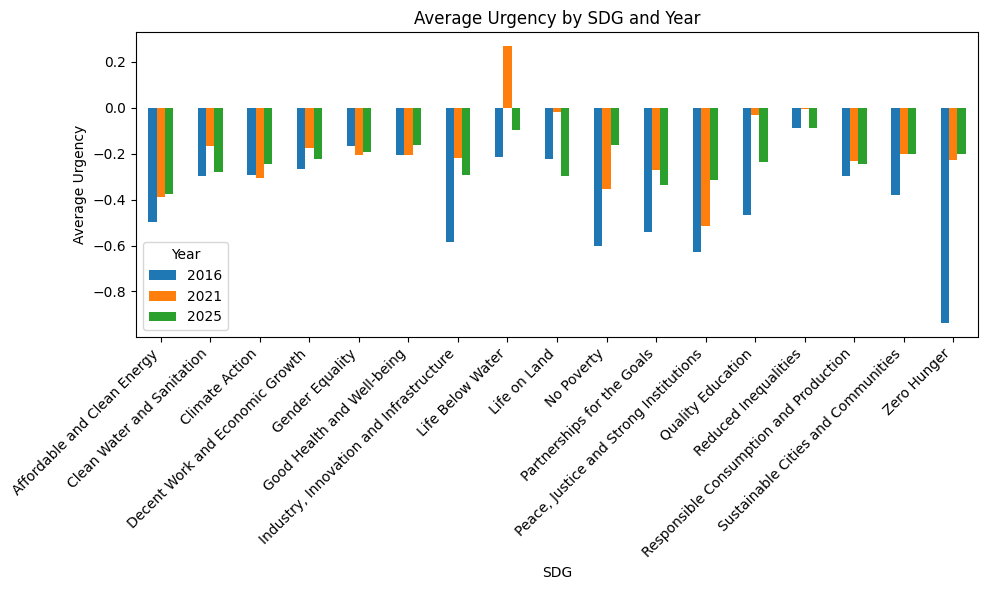

In [361]:
# Which goals show the most regression vs. progress in language?

plot_data = summary.pivot(index='sdg', columns='year', values='urgency')

fig, ax = plt.subplots(figsize=(10, 6))
plot_data.plot(kind='bar', ax=ax)

ax.set_ylabel('Average Urgency')
ax.set_xlabel('SDG')
ax.set_title('Average Urgency by SDG and Year')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

This plot shows the comparisons of average urgency score per year. The 2016 scores have more extreme, positive averages than all the other reports. The 2021 report has the most variation amongst the urgency scores of the goals. The 2025 reports are all consistently around the same ratings, being slightly positive.

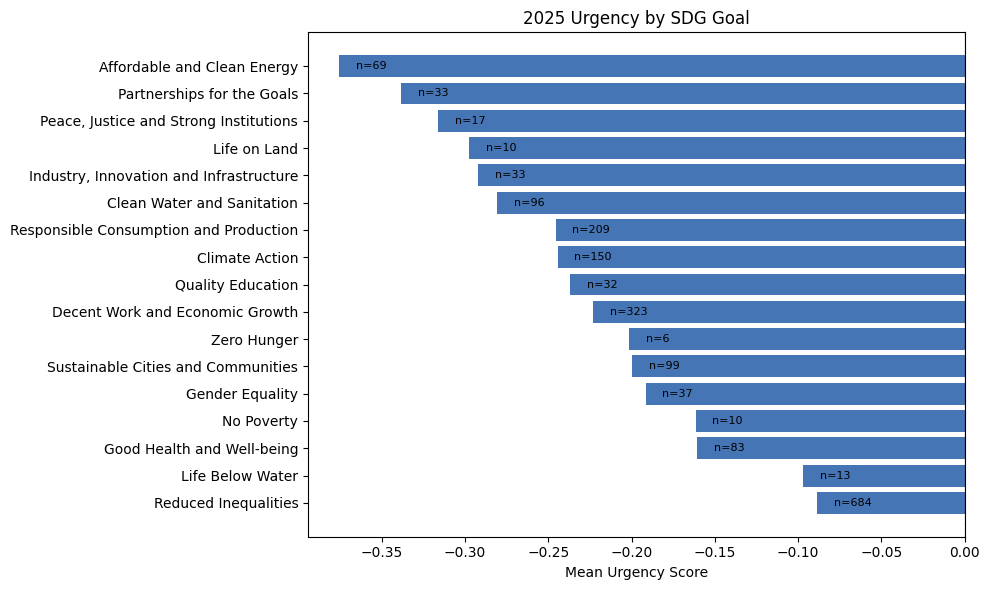

In [ ]:
urgency_by_sdg_full = (df_2025.groupby('sdg')['urgency'].agg(['mean', 'count']).sort_values('mean', ascending= True))

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in urgency_by_sdg_full['mean']]
bars = ax.barh(urgency_by_sdg_full.index, urgency_by_sdg_full['mean'], color=colors)

for bar, (_, row) in zip(bars, urgency_by_sdg_full.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}", va='center', fontsize=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Urgency Score')
ax.set_title('2025 Urgency by SDG Goal')
ax.invert_yaxis()  
plt.tight_layout()
plt.show()

Reduced inequality, life below water, and good health were rated as the most urgent/negative scores in the 2025 report. That makes sense because those are 3 issues that are prevalent in today and what I see most on the news and in articles. Many countries face inequalities, the oceans are polluted and some marinelife species are struggling, and health (mental and physical) is being emphasized as an important factor in life. All of the urgency scores of the top 3 are supported  by a substantial number of sentences, ensuring accuracy amongst these rankings

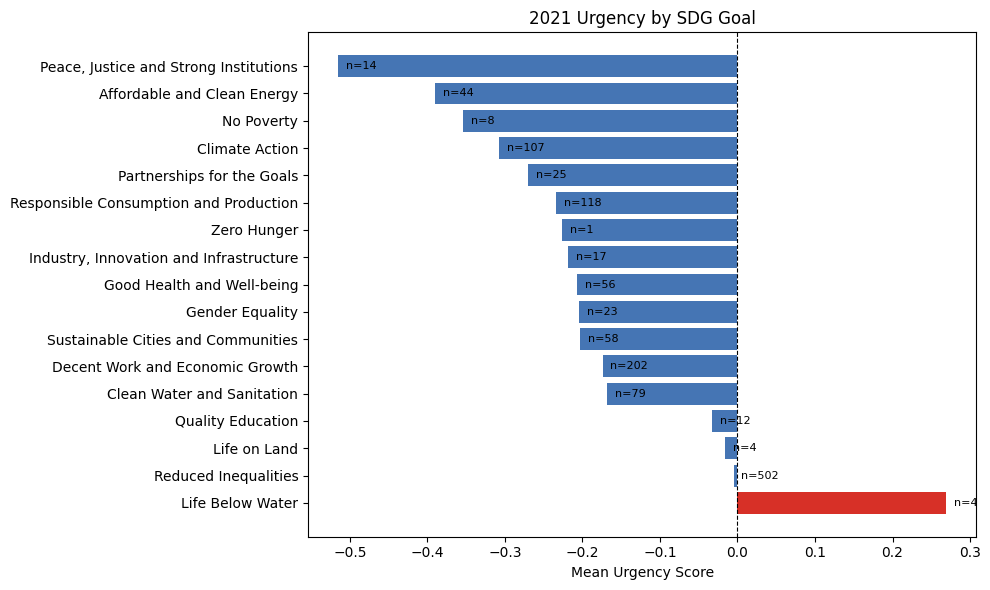

In [376]:
urgency_by_sdg_full = (df_2021.groupby('sdg')['urgency'].agg(['mean', 'count']).sort_values('mean', ascending= True))

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in urgency_by_sdg_full['mean']]
bars = ax.barh(urgency_by_sdg_full.index, urgency_by_sdg_full['mean'], color=colors)

for bar, (_, row) in zip(bars, urgency_by_sdg_full.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}", va='center', fontsize=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Urgency Score')
ax.set_title('2021 Urgency by SDG Goal')
ax.invert_yaxis()  
plt.tight_layout()
plt.show()

Life Below Water was classified as severely urgent and negative due to the current crisis with ocean pollution. There were only 4 sentences that were labeled as Life Below Water, which could skew the data since it hasn't been normalized by enough samples. Reduced Inequalities and Life on Land both had higher urgency scores compared to the rest of the goals. Life on Land faces the same issues as Life Below Water with only having a sample size of 4, which is not enough to definitively say that this urgency rating is accurate. On the other hand, Reduced Inequalities has 502 samples, yet still places at very urgent, making this score very accurate. COVID-19 also might have played a role in the urgent sentiment of the report because they were looking to solve issues while the world was shut down and emphasize the importance of the goals to everyone reading the report.

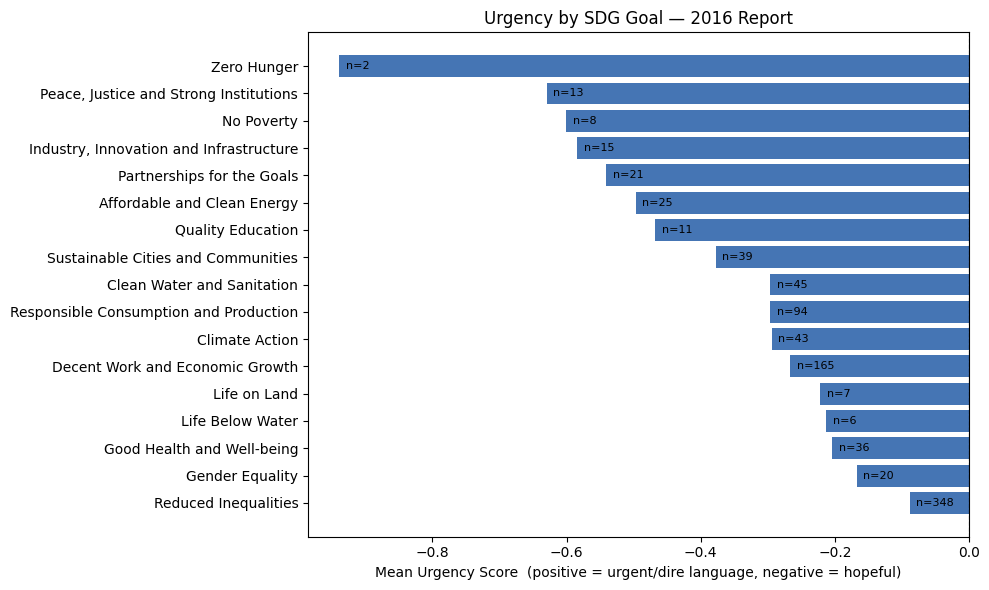

In [ ]:
#bar chart of urgency by sdg

urgency_by_sdg_full = (df_2016.groupby('sdg')['urgency'].agg(['mean', 'count']).sort_values('mean', ascending= True))

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in urgency_by_sdg_full['mean']]
bars = ax.barh(urgency_by_sdg_full.index, urgency_by_sdg_full['mean'], color=colors)

for bar, (_, row) in zip(bars, urgency_by_sdg_full.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['count'])}", va='center', fontsize=8)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Urgency Score')
ax.set_title('2016 Urgency by SDG Goal')
ax.invert_yaxis()  
plt.tight_layout()
plt.show()

Reduced Inequalities, Gender Equality, and Good Health and Well Being were rated as having the highest urgency scores for the 2016 report. All of these had good sample sizes, making the given scores accurate.

In [457]:
progress_data = {
    'sdg': [
        'No Poverty', 'Zero Hunger', 'Good Health and Well-being','Quality Education', 'Gender Equality', 'Clean Water and Sanitation','Affordable and Clean Energy', 'Decent Work and Economic Growth','Industry, Innovation and Infrastructure', 'Reduced Inequalities','Sustainable Cities and Communities', 'Responsible Consumption and Production','Climate Action', 'Life Below Water', 'Life on Land', 'Peace, Justice and Strong Institutions', 'Partnerships for the Goals'],
    2021: [0, -1, 1, 0, 0, 0, 1, -1,1 , 0, -1, 0, -1, 0, -1, 0, 1],
    2025: [0, -1, 0, -1, 0, -1, 1, -1,1, -1, 0, 0, 1, -1, 0, 0, 1]
}

df_progress = pd.DataFrame(progress_data)
df_progress_long = df_progress.melt(
    id_vars='sdg', var_name='year', value_name='progress_score'
)
df_progress_long['year'] = df_progress_long['year'].astype(int)

In [458]:
urgency_by_goal_year = (
    df_master.groupby(['sdg', 'year'])['urgency']
    .mean()
    .reset_index()
)

merged = urgency_by_goal_year.merge(df_progress_long, on=['sdg', 'year'])
print(merged)

                                        sdg  year   urgency  progress_score
0               Affordable and Clean Energy  2021 -0.389834               1
1               Affordable and Clean Energy  2025 -0.375481               1
2                Clean Water and Sanitation  2021 -0.167991               0
3                Clean Water and Sanitation  2025 -0.280476              -1
4                            Climate Action  2021 -0.306963              -1
5                            Climate Action  2025 -0.244340               1
6           Decent Work and Economic Growth  2021 -0.173771              -1
7           Decent Work and Economic Growth  2025 -0.222898              -1
8                           Gender Equality  2021 -0.203917               0
9                           Gender Equality  2025 -0.191570               0
10               Good Health and Well-being  2021 -0.206804               1
11               Good Health and Well-being  2025 -0.160445               0
12  Industry

In [459]:
from scipy.stats import spearmanr

corr, pvalue = spearmanr(merged['urgency'], merged['progress_score'])
print(f"Spearman r = {corr:.3f}, p = {pvalue:.3f}")

Spearman r = -0.356, p = 0.039


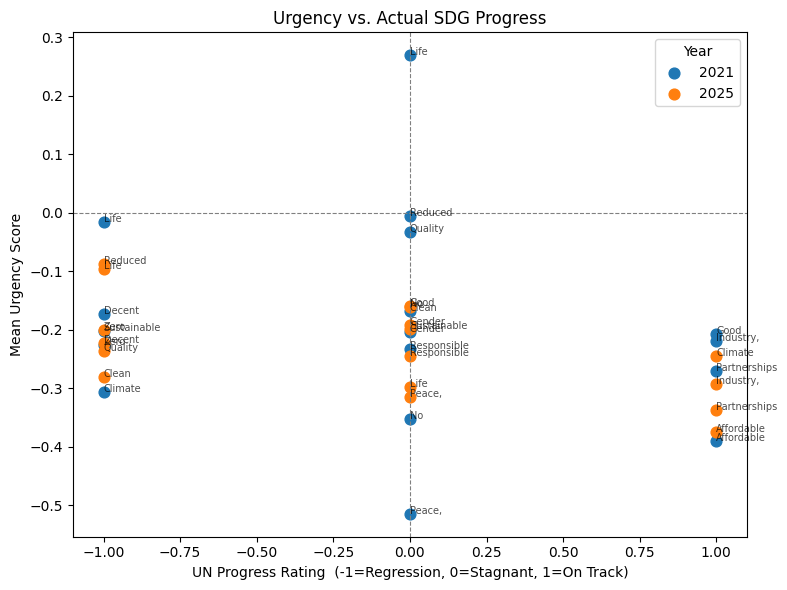

In [461]:
fig, ax = plt.subplots(figsize=(8, 6))

for year, group in merged.groupby('year'):
    ax.scatter(group['progress_score'], group['urgency'], label=str(year), s=60)
    for _, row in group.iterrows():
        ax.annotate(row['sdg'].split()[0], 
                    (row['progress_score'], row['urgency']),
                    fontsize=7, alpha=0.7)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('UN Progress Rating  (-1=Regression, 0=Stagnant, 1=On Track)')
ax.set_ylabel('Mean Urgency Score')
ax.set_title('Urgency vs. Actual SDG Progress')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

This visualization shows the relationship between the urgency score and actual sdg progress (pulled directly from the reports). There is a high correlation between the two features, meaning that the high urgency score in the text is because the progress for the goal is either remaining stagnant or declining. Life Below Water and Reduced Inequalities were the highest notable features that display high urgency and regression for goal progress.

# Conclusion


### How have the sentiments of the reports changed from 2016 to 2025? 

In terms of urgency, all of the years have lenient and positive sentiment, however, the reports have shifted to have less variation and be more consistent. Urgency peaked in 2021 and has partially recovered in 2025 but language is still more urgent than 2016. When the report started in 2016, there was more deviation amongst the urgency scores of the individual goals and hyper-positive messages about the status of the SDG's. In the 2021 report, the urgency scores became more consistent with a few outliers. In 2025, the report's urgency had a standard score across all goals with little variation or deviation away from around -.2. The intensity and urgency of these goals has not really changed drastically over the past 10 years, but writing style has changed. The UN is looking for the best way to convey their message, while still being able to emphasize specific concerns. 


### Which goals changed the most from 2016 to 2025? 

From 2016 to 2025, No Poverty, Zero Hunger, and Industry,Innovation, and Infrastructure ranked as having the highest differences. In 2016, these three SDG's were ranked as not very urgent and very positive, but reduced by nearly a third to be kind of more moderate. The positive ratings in 2016 can be attributed to not wanting to be too critical in the first report ever released. As years passed, they realised the importance of emphasizing the urgency as a call to action. In 2025, nearly all of the goals have a moderately urgent tone because progress is being reversed and we are in a worse state than when the report started. Reduced Inequalities was in the top 3 urgency ratings for all three reports, exemplifying its significance over the past 10 years. There is a substantial amount of samples that validate its prevalence and importance, validating the accuracy of the metric and making it one of the most important/urgent SDG goals. Additionally, the model shows a tendency to over-assign 'Reduced Inequalities' as a label, which may inflate its apparent prevalence across all three reports. The past 10 years have gone through a lot of change with the rise of Artificial Intelligence, COVID-19, and War in many different countries. The urgency scores could reflect geopolitical climates and tensions by writing messages to push hard with trends to influence the world to make a difference. 


### Does the classifier work? 

The SDG Label works well at identifying obvious classifications, which is very important on large texts. The model generated over 3,000 labels for 3 different reports that would take time off a humans hands and reduce error. The classifier had trouble assigning labels to sentences that didn't have obvious topics or lacked enough valuable information and would assign a label that wasn't exactly accurate. There should be a "neutral" label for sentences that don't fall into any category and are more fluff information that don't have statistical importance to the report. With this consideration, there might be inaccuracies in the count of SDG Goals because sentences with strictly information were classified into a goal. 


### Business Implication
This method could help policy teams, UN employees, and researchers understand how the reports have changed over the past 10 years in efforts to understand the impacts of the semantics of the document. The textual significance could be compared to analysis on the progress of the goals to examine if there is a relationship between how the reports are written and any policy change.


### Significance of Results

The results show how much the report has changed over the past ten years since the start and what the United Nations (UN) finds important to communicate. There has been a shift in how sentiment/urgency of the different years, showing how the UN has been experimenting with the most effective ways of communication. We have also seen a shift in which goals were considered the most important. Reduced Inequalities is the only SDG that remained in all three examined reports, but there was a rise in the prevalence of Life Below Water and Good Health/Well Being. As 2030 nears, I expect all of the SDG's in the future reports to have increasing urgency and consistency amongst all goals. We have seen the reports have more regularized sentiments with intense tones because we are struggling to see results. The overall goal was to accomplish all SDG's by the year 2030, however much of the progress has either remained the same, or even decreased. I expect to continue to see Reduced Inequalities remain in the top goals, while other goals will rise, following the variation that we have seen in the past reports.